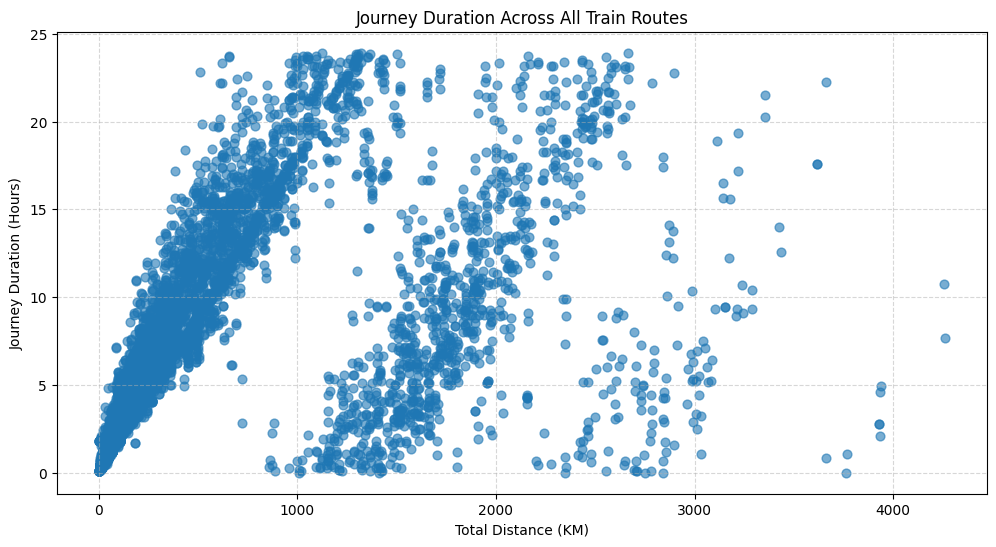

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Dataset1.csv")

df = df.sort_values(["Train_No", "SN"])

df["Arrival_time"] = pd.to_datetime(df["Arrival_time"], format="%H:%M:%S")
df["Departure_Time"] = pd.to_datetime(df["Departure_Time"], format="%H:%M:%S")

journey = df.groupby("Train_No").agg(
    Start_Station=("Station_Name", "first"),
    End_Station=("Station_Name", "last"),
    Start_Time=("Departure_Time", "first"),
    End_Time=("Arrival_time", "last"),
    Total_Distance=("Distance", "max")
).reset_index()

journey.loc[
    journey["End_Time"] < journey["Start_Time"],
    "End_Time"
] += pd.Timedelta(days=1)

journey["Journey_Hours"] = (
    journey["End_Time"] - journey["Start_Time"]
).dt.total_seconds() / 3600

journey["Route"] = journey["Start_Station"] + " to " + journey["End_Station"]


plt.figure(figsize=(12, 6))

plt.scatter(
    journey["Total_Distance"],
    journey["Journey_Hours"],
    alpha=0.6,
    s=40
)

plt.xlabel("Total Distance (KM)")
plt.ylabel("Journey Duration (Hours)")
plt.title("Journey Duration Across All Train Routes")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

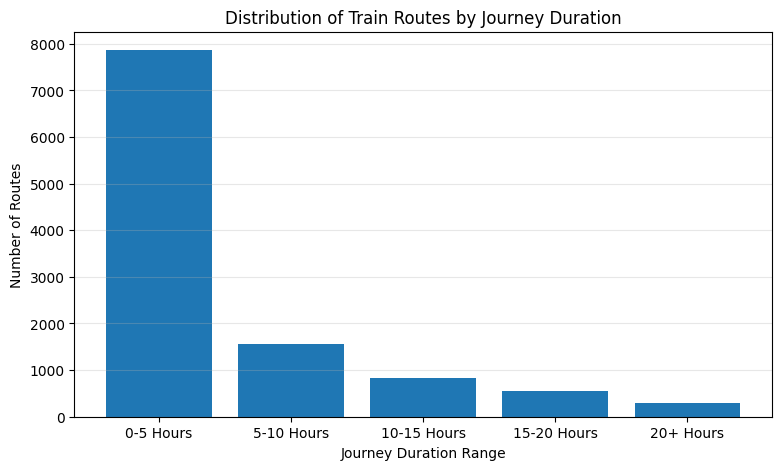

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Create duration categories
journey["Duration_Category"] = pd.cut(
    journey["Journey_Hours"],
    bins=[0,5,10,15,20,25],
    labels=[
        "0-5 Hours",
        "5-10 Hours",
        "10-15 Hours",
        "15-20 Hours",
        "20+ Hours"
    ]
)

duration_count = journey["Duration_Category"].value_counts().sort_index()


plt.figure(figsize=(9,5))

plt.bar(
    duration_count.index,
    duration_count.values
)

plt.xlabel("Journey Duration Range")
plt.ylabel("Number of Routes")

plt.title("Distribution of Train Routes by Journey Duration")

plt.grid(axis="y", alpha=0.3)

plt.show()